# EDA — Preu dels allotjaments Airbnb a Mallorca

Aquest notebook explora el conjunt predictiu generat per `build_model_datasets.py`. L'objectiu és entendre la distribució del preu, els extrems, els nuls i la relació entre el preu i les característiques dels allotjaments.

No modifica cap fitxer de dades.

## 1. Preparació

Carregar les llibreries per treballar amb les dades i fer les visualitzacions. 

Es configuren alguns paràmetres de `pandas` i `seaborn` per facilitar la lectura dels resultats.

El conjunt de dades que utilitzarem es troba en format Parquet dins la carpeta `code/data/model/`.

In [46]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuració bàsica
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}") # 1234.56789 es veu com 1,234.57


# Ruta del projecte
project_root = Path.cwd()
project_root = project_root.parents[1] # Pujam fins a l'arrel del TFM

# Ruta del conjunt de dades
data_path = project_root / "code" / "data" / "model" / "model_dataset_predictive.parquet"

# Carpeta gràfics
output_path = project_root / "code" / "outputs"

### Càrrega del conjunt de dades

Cream una variable que indiqui si cada allotjament té alguna ressenya. 

In [35]:
# Carregam les dades
df = pd.read_parquet(data_path)

# Variable per si l'allotjament té ressenyes
df["has_reviews"] = (df["number_of_reviews"].fillna(0) > 0).astype(int)

print(f"Files: {len(df):,}")
print(f"Columnes: {len(df.columns):,}")

df.head()

Files: 15,027
Columnes: 53


,listing_id,price_numeric,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,instant_bookable,host_is_superhost,host_response_time,host_response_rate_numeric,host_acceptance_rate_numeric,calculated_host_listings_count,host_tenure_days,amenities_count,has_license,availability_365,has_reviews,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,bathrooms_missing,bedrooms_missing,beds_missing,number_of_reviews_missing,number_of_reviews_ltm_missing,number_of_reviews_l30d_missing,reviews_per_month_missing,review_scores_rating_missing,review_scores_accuracy_missing,review_scores_cleanliness_missing,review_scores_checkin_missing,review_scores_communication_missing,review_scores_location_missing,review_scores_value_missing,host_response_rate_numeric_missing,host_acceptance_rate_numeric_missing,host_tenure_days_missing,calculated_host_listings_count_missing
0,69998,164.00,Palma de Mallorca,39.57,2.65,Entire loft,Entire home/apt,2,1.00,1.00,1.00,32,250,t,f,within an hour,100,100,2,"5,359.00",43,0,309,1,266,2,0,1.60,4.95,4.92,4.94,4.95,4.97,4.89,4.81,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,106833,200.00,Sant Llorenç des Cardassar,39.61,3.30,Entire villa,Entire home/apt,4,1.00,2.00,4.00,5,20,f,f,within a day,100,86,1,"5,256.00",13,1,5,1,32,5,1,0.20,4.88,4.84,4.84,4.91,4.94,4.56,4.66,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,159218,160.00,Selva,39.79,2.91,Entire cottage,Entire home/apt,3,1.00,1.00,2.00,4,365,f,t,within an hour,100,100,2,"5,197.00",69,1,308,1,407,28,2,2.38,4.92,4.88,4.93,4.96,4.95,4.82,4.75,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,166820,75.00,Banyalbufar,39.68,2.50,Private room in home,Private room,2,1.00,1.00,1.00,1,365,t,f,within an hour,100,92,3,"5,189.00",34,1,250,1,359,45,3,2.09,4.68,4.75,4.35,4.86,4.91,4.94,4.59,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,210156,92.00,Alcúdia,39.83,3.11,Private room in chalet,Private room,2,2.00,1.00,1.00,7,14,f,t,within a few hours,100,95,3,"5,137.00",47,1,0,1,132,6,1,0.83,4.91,4.96,4.96,4.96,4.97,4.70,4.84,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2. Estructura, tipus i nuls

Per a cada variable veurem el seu tipus, el nombre i percentatge de valors nuls i el nombre de valors diferents.

Calcularem el percentatge de valors nuls i el representarem gràficament.

In [ ]:
# Informació bàsica de les variables
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100,
    "unique": df.nunique()
})

# Ordenam el resum
summary = summary.sort_values(
    ["missing_percentage", "unique"], ascending=[False, False]
)

summary

,dtype,missing,missing_percentage,unique
listing_id,int64,0,0.00,15027
longitude,float64,0,0.00,13567
latitude,float64,0,0.00,13494
host_tenure_days,float64,0,0.00,2716
price_numeric,Float64,0,0.00,1287
reviews_per_month,float64,0,0.00,519
availability_365,int64,0,0.00,366
number_of_reviews,int64,0,0.00,335
review_scores_cleanliness,float64,0,0.00,170
review_scores_value,float64,0,0.00,164


In [ ]:
# Variables que indiquen si hi havia nuls originalment
missing_flags = [col for col in df.columns if col.endswith("_missing")]

# Percentatge de dades que faltaven originalment
missing_rates = df[missing_flags].mean() * 100
missing_rates = missing_rates.sort_values(ascending=False)

missing_rates

review_scores_value_missing              19.37
review_scores_location_missing           19.37
review_scores_checkin_missing            19.37
review_scores_communication_missing      19.37
review_scores_cleanliness_missing        19.37
review_scores_accuracy_missing           19.37
review_scores_rating_missing             19.37
reviews_per_month_missing                19.37
host_response_rate_numeric_missing        3.35
host_acceptance_rate_numeric_missing      2.84
beds_missing                              0.09
host_tenure_days_missing                  0.03
bathrooms_missing                         0.02
bedrooms_missing                          0.01
number_of_reviews_ltm_missing             0.00
number_of_reviews_missing                 0.00
number_of_reviews_l30d_missing            0.00
calculated_host_listings_count_missing    0.00
dtype: float64

## 3. Distribució del preu i extrems

Estudiam la distribució de la variable `price_numeric`. Calculam la mitjana i la mediana per veure si són molt diferents

Calcularem els quartils i el rang interquartílic (IQR) per obtenir un límit superior a partir del qual considerarem que un preu és extrem. També representarem 
- la distribució del preu, 
- la distribució de `log(1 + preu)`,
- el boxplot.

In [44]:
# Preus disponibles
price = df["price_numeric"].dropna()


# Quartils i rang interquartílic
q1 = price.quantile(0.25)
q3 = price.quantile(0.75)
iqr = q3 - q1

lower_iqr = q1 - 1.5 * iqr
upper_iqr = q3 + 1.5 * iqr


# Estadística descriptiva
price.describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).to_frame("price")

,price
count,"15,027.00"
mean,"1,512.97"
std,"3,047.83"
min,10.00
1%,58.00
5%,91.00
25%,170.00
50%,275.00
75%,527.00
95%,"9,999.00"


La variable `price` presenta una distribució asimètrica. La mediana és de 275€, mentre que la mitjana puja fins als 1.512,97€.
Això indica que els preus molt elevats tenen un efecte important sobre la mitjana. 

A més, el 75% dels allotjaments tenen un preu inferior a 527€, mentre que els percentils 95 i 99 se situen pràcticament en 10.000€.

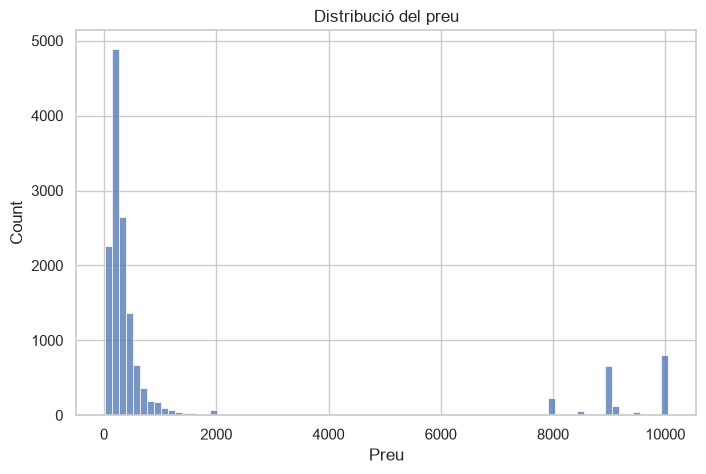

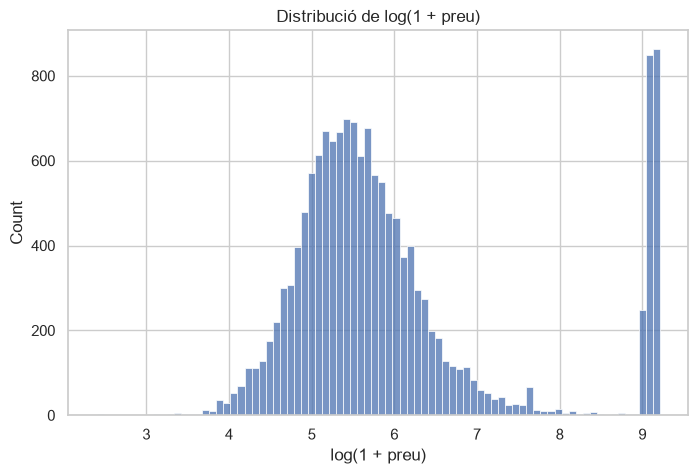

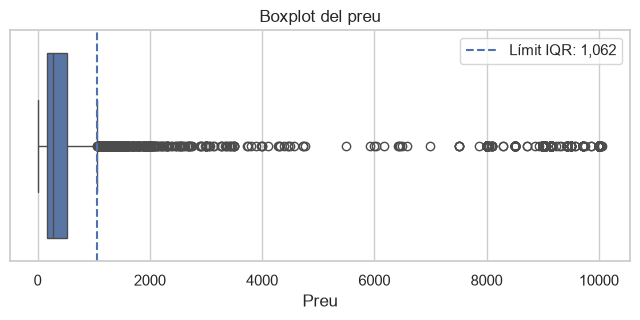

In [47]:
# Distribució del preu
plt.figure(figsize=(8, 5))
sns.histplot(price, bins=80)
plt.xlabel("Preu")
plt.title("Distribució del preu")

plt.savefig(output_path / "price_distribution.pdf", bbox_inches="tight")
plt.show()


# Distribució en escala logarítmica
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(price), bins=80)
plt.xlabel("log(1 + preu)")
plt.title("Distribució de log(1 + preu)")

plt.savefig(output_path / "price_log_distribution.pdf", bbox_inches="tight")
plt.show()


# Boxplot
plt.figure(figsize=(8, 3))
sns.boxplot(x=price)
plt.axvline(
    upper_iqr,
    linestyle="--",
    label=f"Límit IQR: {upper_iqr:,.0f}"
)
plt.xlabel("Preu")
plt.title("Boxplot del preu")
plt.legend()

plt.savefig(output_path / "price_boxplot.pdf", bbox_inches="tight")
plt.show()

#### Distribució del preu

La major part dels allotjaments es concentren en preus relativament baixos, mentre que apareix una cua molt llarga cap a valors elevats. També s'observa una concentració important al voltant dels 10.000 €, que correspon als valors extrems.


#### Distribució logarítmica

En aplicar `log(1 + preu)`, la distribució queda molt més comprimida i permet observar millor la variabilitat dels preus baixos i mitjans. 
Aquesta transformació és útil per reduir l'efecte de l'asimetria de la variable original.

#### Boxplot

El rang interquartílic dona un límit superior de 1.062,50€. Per tant, 2.417 observacions, un 16,08% del conjunt, superen aquest valor i són classificades com a valors extrems segons el criteri de l'IQR. El boxplot mostra clarament aquesta gran quantitat de valors allunyats de la zona central de la distribució.

In [49]:
# Observacions que superen el límit superior de l'IQR
outliers = df[df["price_numeric"] > upper_iqr].copy()

print(f"Límit superior IQR: {upper_iqr:,.2f}")
print(
    f"Files amb preu alt extrem: {len(outliers):,} "
    f"({100 * len(outliers) / len(df):.2f}%)"
)


# Mostram els 20 preus més elevats amb les següents columnes
columns = [
    "listing_id",
    "price_numeric",
    "neighbourhood_cleansed",
    "property_type",
    "room_type",
    "accommodates",
    "bedrooms",
    "bathrooms"
]

outliers.nlargest(20, "price_numeric")[columns]

Límit superior IQR: 1,062.50
Files amb preu alt extrem: 2,417 (16.08%)


,listing_id,price_numeric,neighbourhood_cleansed,property_type,room_type,accommodates,bedrooms,bathrooms
5525,42754810,"10,053.00",Alcúdia,Entire home,Entire home/apt,12,6.00,4.00
14641,1481270875814654034,"10,036.00",Alcúdia,Entire villa,Entire home/apt,7,4.00,2.00
15020,1513156255432415546,"10,036.00",Pollença,Entire home,Entire home/apt,9,5.00,1.00
4015,30393179,"10,032.00",Santanyí,Entire home,Entire home/apt,6,3.00,4.00
11748,1179754093564718270,"10,031.00",Alcúdia,Entire home,Entire home/apt,6,4.00,2.00
11716,1173986433543302236,"10,027.00",Sa Pobla,Entire villa,Entire home/apt,6,3.00,4.00
11955,1212369308801591522,"10,026.00",Santa Margalida,Entire home,Entire home/apt,6,3.00,2.00
14783,1490685360401377723,"10,026.00",Santanyí,Entire rental unit,Entire home/apt,4,2.00,2.00
6799,49648040,"10,018.00",Alcúdia,Entire rental unit,Entire home/apt,4,2.00,1.00
6800,49648207,"10,018.00",Alcúdia,Entire rental unit,Entire home/apt,4,2.00,1.00


## 4. Preu segons tipologia i capacitat

Estudiam com varia el preu segons el tipus d'allotjament i el nombre de persones que pot acollir.

Per comparar les distribucions utilitzarem boxplots. No mostrarem els valors extrems directament en els gràfics, ja que dificulten la comparació entre grups.

Després, estudiarem les diferències de preu entre els diferents municipis de Mallorca. Calcularem el 
- nombre d'anuncis, 
- la mitjana i la mediana del preu per municipi,
- representarem els 20 municipis amb la mediana més elevada.

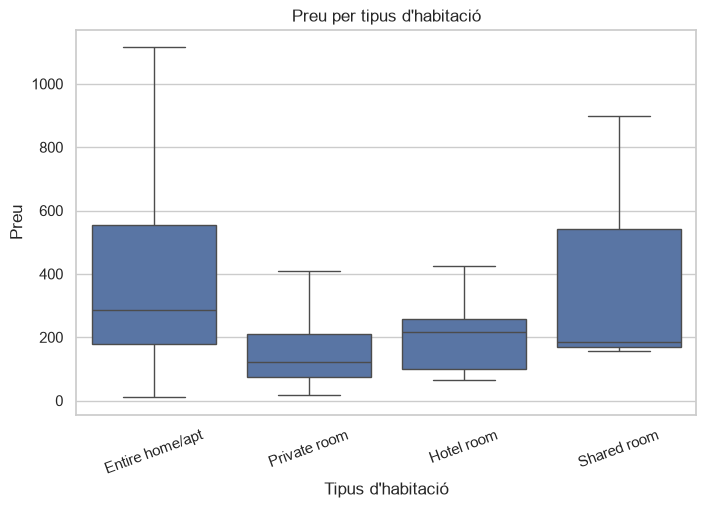

In [50]:
# Preu segons el tipus d'habitació
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="room_type",
    y="price_numeric",
    showfliers=False
)

plt.title("Preu per tipus d'habitació")
plt.xlabel("Tipus d'habitació")
plt.ylabel("Preu")
plt.xticks(rotation=20)

plt.savefig(output_path / "price_by_room_type.pdf", bbox_inches="tight")
plt.show()

#### Tipus d'allotjament

El preu varia clarament segons el tipus d'habitació. Els allotjaments de tipus `Entire home/apt` presenten, en general, preus superiors als de les habitacions privades, mentre que les categories `Hotel room` i `Shared room` presenten preus més baixos d'acord a com ens diu la lògica.

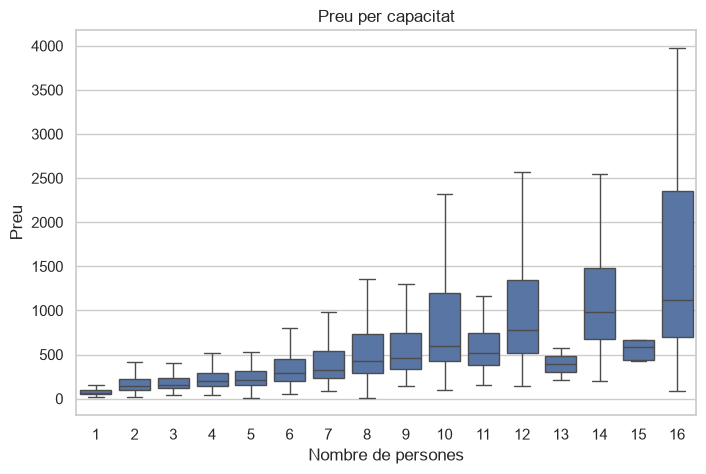

In [52]:
# Preu segons el nombre de persones
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="accommodates",
    y="price_numeric",
    showfliers=False
)

plt.title("Preu per capacitat")
plt.xlabel("Nombre de persones")
plt.ylabel("Preu")

plt.savefig(output_path / "price_by_capacity.pdf", bbox_inches="tight")
plt.show()

#### Capacitat de l'allotjament

S'observa una relació entre la capacitat (`accommodates`) i el preu. En general, els allotjaments amb capacitat per a més persones presenten preus més elevats. Tot i això, la dispersió dels preus és considerable i la relació no és lineal. Això indica que la capacitat, per si sola, no explica tot el preu, però és una característica que pot aportar informació al model.

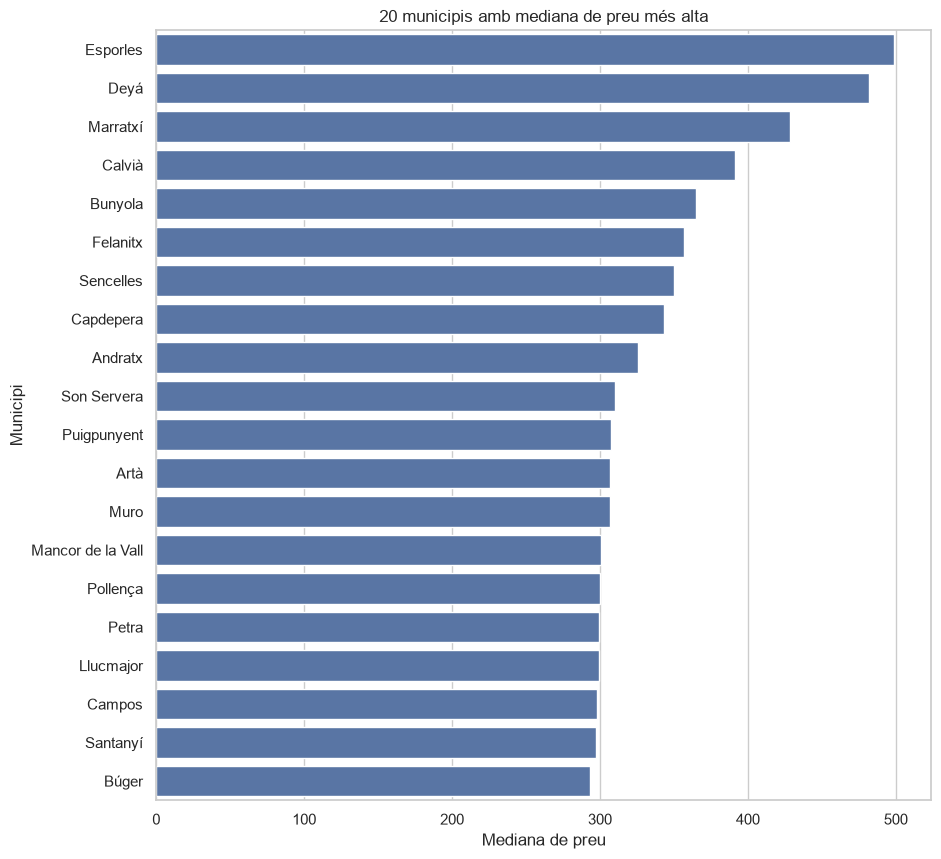

In [55]:
# Resum del preu per municipi
neighbourhood_summary = df.groupby("neighbourhood_cleansed")["price_numeric"].agg(
    announcements="size",
    median="median",
    mean="mean"
)

# Només consideram municipi amb almenys 30 anuncis
neighbourhood_summary = neighbourhood_summary[
    neighbourhood_summary["announcements"] >= 30
]

# Ordenam de major a menor mediana
neighbourhood_summary = neighbourhood_summary.sort_values(
    "median",
    ascending=False
)

# 20 municipis amb la mediana de preu més alta
top_neighbourhoods = neighbourhood_summary.head(20).reset_index()

plt.figure(figsize=(10, 10))

sns.barplot(
    data=top_neighbourhoods,
    x="median",
    y="neighbourhood_cleansed"
)

plt.title("20 municipis amb mediana de preu més alta")
plt.xlabel("Mediana de preu")
plt.ylabel("Municipi")

plt.savefig(output_path / "top_20_neighbourhoods_by_price.pdf", bbox_inches="tight")
plt.show()

#### Diferències entre municipis

S'observen diferències entre els municipis. Per tant, la localització sembla tenir una relació important amb el preu. Això reforça la idea que les característiques geogràfiques poden tenir un paper important en la predicció del preu.

## 5. Component geogràfic

En aquest apartat estudiarem la distribució geogràfica dels allotjaments i la seva relació amb el preu.

Utilitzarem les coordenades de latitud i longitud de cada allotjament. El color dels punts representarà el valor de `log(1 + preu)`.

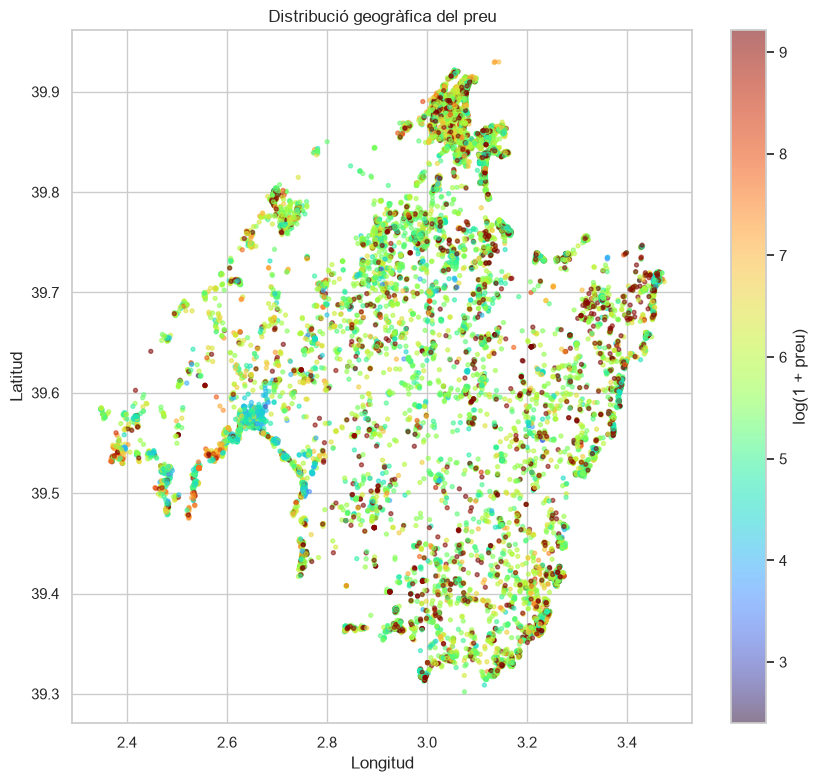

In [59]:
# Seleccionam els allotjaments amb coordenades i preu disponibles
geo = df.dropna(subset=["latitude", "longitude", "price_numeric"])

plt.figure(figsize=(10, 9))

scatter = plt.scatter(
    geo["longitude"],
    geo["latitude"],
    c=np.log1p(geo["price_numeric"]),
    cmap="turbo",
    s=8,
    alpha=0.55
)

plt.colorbar(scatter, label="log(1 + preu)")
plt.title("Distribució geogràfica del preu")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.savefig(
    output_path / "geographical_price_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

## 6. Ressenyes, disponibilitat i correlacions

En aquest apartat estudiarem la relació entre les ressenyes i el preu dels allotjaments.

Primer compararem el preu dels allotjaments amb i sense ressenyes. Després estudiarem la relació entre el nombre de ressenyes mensuals i el preu mitjançant un gràfic de dispersió. Finalment, calcularem la correlació de Pearson entre el preu i les diferents variables numèriques del conjunt de dades. 

In [60]:
# Preu segons si l'allotjament té ressenyes
review_price = df.groupby("has_reviews")["price_numeric"].agg(
    ["size", "median", "mean"]
)

review_price.index = ["Sense ressenyes", "Amb ressenyes"]

review_price

,size,median,mean
Sense ressenyes,2910,441.00,"2,628.85"
Amb ressenyes,12117,252.00,"1,244.98"


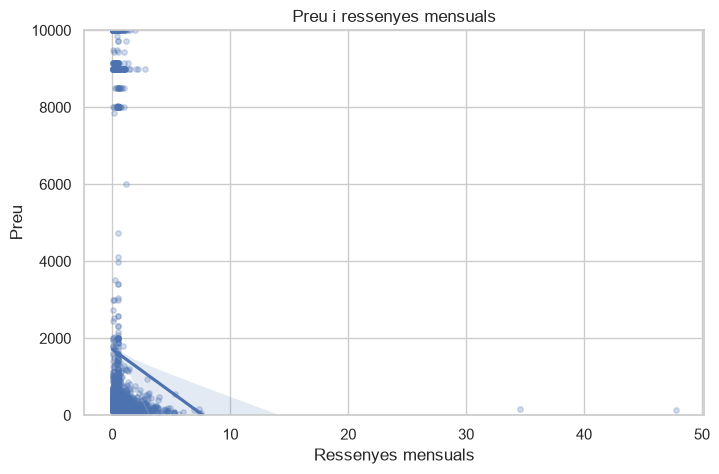

In [61]:
# Relació entre ressenyes mensuals i preu
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df.sample(min(3000, len(df)), random_state=42),
    x="reviews_per_month",
    y="price_numeric",
    scatter_kws={"alpha": 0.25, "s": 15}
)

# Limitam l'eix vertical al percentil 99 per veure millor la relació
plt.ylim(0, price.quantile(0.99))

plt.title("Preu i ressenyes mensuals")
plt.xlabel("Ressenyes mensuals")
plt.ylabel("Preu")

plt.savefig(
    output_path / "price_and_monthly_reviews.pdf",
    bbox_inches="tight"
)

plt.show()

El gràfic mostra una gran dispersió entre `reviews_per_month` i el preu, sense una tendència lineal gaire marcada. Això és coherent amb la correlació de −0,11 que indica una relació negativa i feble. 

In [62]:
# Seleccionam les variables numèriques
numeric_columns = df.select_dtypes(include=np.number).columns

# Eliminam els indicadors de dades mancants i l'identificador
numeric_columns = [
    column for column in numeric_columns
    if not column.endswith("_missing") and column != "listing_id"
]

# Correlació de cada variable numèrica amb el preu
correlations = df[numeric_columns].corr()["price_numeric"].sort_values()

correlations

host_tenure_days                 -0.39
has_reviews                      -0.18
number_of_reviews                -0.15
number_of_reviews_l30d           -0.14
number_of_reviews_ltm            -0.14
minimum_nights                   -0.13
amenities_count                  -0.12
reviews_per_month                -0.11
latitude                         -0.04
review_scores_value              -0.02
review_scores_location           -0.01
review_scores_communication      -0.01
review_scores_accuracy           -0.01
review_scores_rating              0.00
calculated_host_listings_count    0.00
review_scores_checkin             0.00
review_scores_cleanliness         0.02
bathrooms                         0.07
maximum_nights                    0.08
beds                              0.08
accommodates                      0.09
bedrooms                          0.09
host_response_rate_numeric        0.09
longitude                         0.11
host_acceptance_rate_numeric      0.12
has_license              

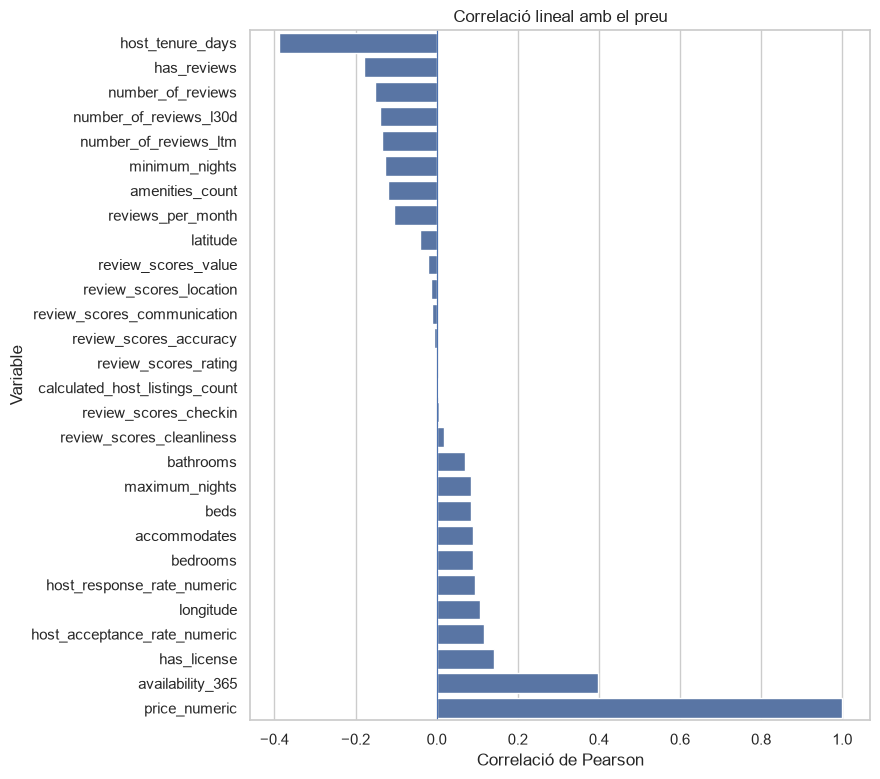

In [63]:
# Representam les correlacions
plt.figure(figsize=(8, max(6, len(correlations) * 0.32)))

sns.barplot(
    x=correlations.values,
    y=correlations.index
)

plt.axvline(0, linewidth=0.8)
plt.title("Correlació lineal amb el preu")
plt.xlabel("Correlació de Pearson")
plt.ylabel("Variable")

plt.savefig(
    output_path / "correlations_with_price.pdf",
    bbox_inches="tight"
)

plt.show()

La variable que presenta una correlació negativa més elevada amb el preu és `host_tenure_days`, amb un valor de −0,39. Això indica que, en aquestes dades, els allotjaments associats a amfitrions amb més antiguitat tendeixen a presentar preus més baixos. És una relació moderada, però bastant més elevada que la de la majoria de variables analitzades.

També s'observa una correlació negativa entre el preu i les variables relacionades amb les ressenyes. Per exemple, `has_reviews` presenta una correlació de −0,18, mentre que `number_of_reviews` és de −0,15 i `reviews_per_month` de −0,11. Per tant, els allotjaments amb més activitat de ressenyes tendeixen a tenir preus una mica més baixos. Encara així la relació és feble.

Per altra banda, la variable amb una correlació positiva més elevada és `availability_365`, amb 0,40. També apareixen correlacions positives, encara que febles, amb `longitude` (0,11), `host_acceptance_rate_numeric` (0,12) i `has_license` (0,14).

Pel que fa a les característiques de l'allotjament, variables com `accommodates` (0,09), `bedrooms` (0,09) i `beds` (0,08) presenten una correlació positiva però baixa. Per tant, la capacitat i les dimensions de l'allotjament tenen una relació positiva amb el preu, però la correlació lineal per si sola no és gaire elevada.